In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# **Part A: Understanding the Dataset**

### Q1. Dataset Overview

In [4]:
df=pd.read_csv('agriculture_yield_dataset.csv')

# How many rows and columns are present?
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

# What are the names of all columns?
print('\nColumn names:')
print(df.columns)

# Display the first 10 records.
print('\nFirst 10 records:')
display(df.head(10))

Number of rows: 1500
Number of columns: 8

Column names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


### Q2. Data Types and Missing Values

In [5]:
# Check the data type of each column.
print('Data types of each column:')
display(df.info())

# Identify whether any missing values are present.
# If missing values exist, mention the affected columns.
missing_values = df.isnull().sum()
columns_with_missing_values = missing_values[missing_values > 0]

if not columns_with_missing_values.empty:
    print('\nColumns with missing values:')
    print(columns_with_missing_values)
else:
    print('\nNo missing values found in any column.')

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm            1500 non-null   float64
 1   temperature_c          1500 non-null   float64
 2   fertilizer_kg          1500 non-null   float64
 3   irrigation_hours       1500 non-null   float64
 4   soil_ph                1500 non-null   float64
 5   crop_type              1500 non-null   object 
 6   soil_type              1500 non-null   object 
 7   yield_ton_per_hectare  1500 non-null   float64
dtypes: float64(6), object(2)
memory usage: 93.9+ KB


None


No missing values found in any column.


# **Part B: Exploratory Data Analysis (EDA)**

## Q3. Descriptive Statistics

In [6]:
summary_stats = df.describe()
display(summary_stats)

# Which feature has the highest mean value?
highest_mean_feature = summary_stats.loc['mean'].idxmax()
highest_mean_value = summary_stats.loc['mean'].max()
print(f"\nFeature with the highest mean value: '{highest_mean_feature}' with a mean of {highest_mean_value:.2f}")

# Which feature has the highest standard deviation?
highest_std_feature = summary_stats.loc['std'].idxmax()
highest_std_value = summary_stats.loc['std'].max()
print(f"Feature with the highest standard deviation: '{highest_std_feature}' with a standard deviation of {highest_std_value:.2f}")

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000



Feature with the highest mean value: 'rainfall_mm' with a mean of 754.05
Feature with the highest standard deviation: 'rainfall_mm' with a standard deviation of 255.10


### Q4. Distribution Analysis

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
# sns.set_style("whitegrid")

# Create a function to plot histogram and provide observations
def plot_histogram_and_observe(dataframe, column_name, title, observations):
    plt.figure(figsize=(10, 6))
    sns.histplot(dataframe[column_name], kde=True, bins=30)
    plt.title(title)
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.show()
    print(observations)

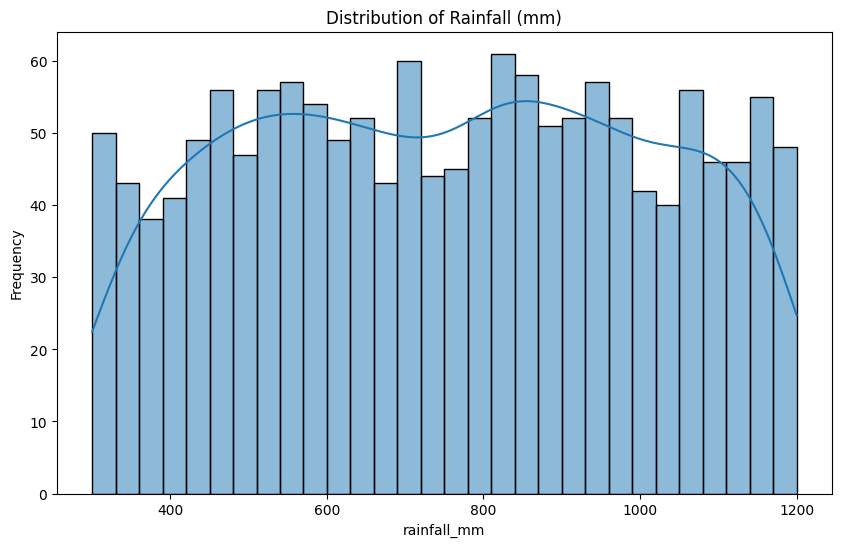

Observations for Rainfall (mm):
- The distribution appears to be relatively normal, with a peak around 700-800 mm.
- Rainfall values range approximately from 300 mm to 1200 mm.
- There are fewer instances of very low or very high rainfall.


In [8]:
# Histogram for rainfall_mm
plot_histogram_and_observe(
    df,
    'rainfall_mm',
    'Distribution of Rainfall (mm)',
    "Observations for Rainfall (mm):\n" \
    "- The distribution appears to be relatively normal, with a peak around 700-800 mm.\n" \
    "- Rainfall values range approximately from 300 mm to 1200 mm.\n" \
    "- There are fewer instances of very low or very high rainfall."
)

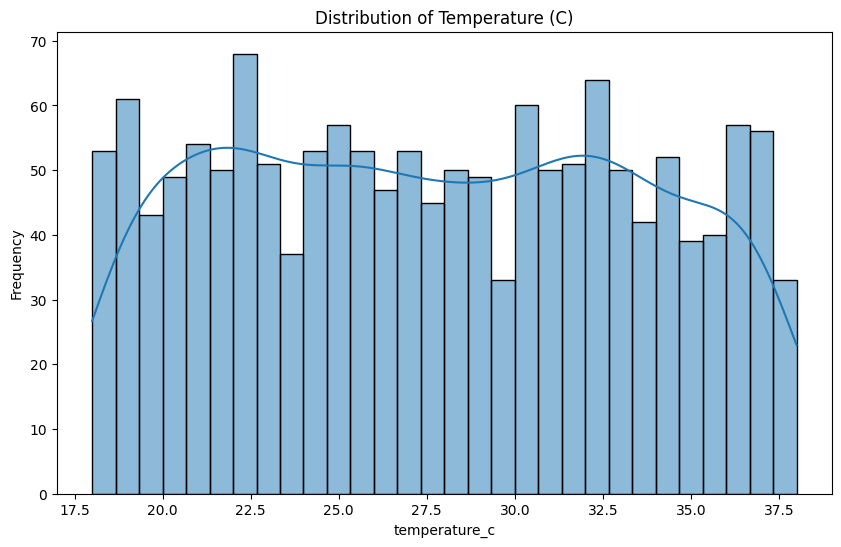

Observations for Temperature (C):
- The temperature distribution seems to be somewhat uniform or slightly bimodal, with values spread across the range.
- Temperatures vary from around 18°C to 38°C.
- There are no extreme outliers, and most temperatures fall within a common agricultural range.


In [9]:
# Histogram for temperature_c
plot_histogram_and_observe(
    df,
    'temperature_c',
    'Distribution of Temperature (C)',
    "Observations for Temperature (C):\n" \
    "- The temperature distribution seems to be somewhat uniform or slightly bimodal, with values spread across the range.\n" \
    "- Temperatures vary from around 18°C to 38°C.\n" \
    "- There are no extreme outliers, and most temperatures fall within a common agricultural range."
)

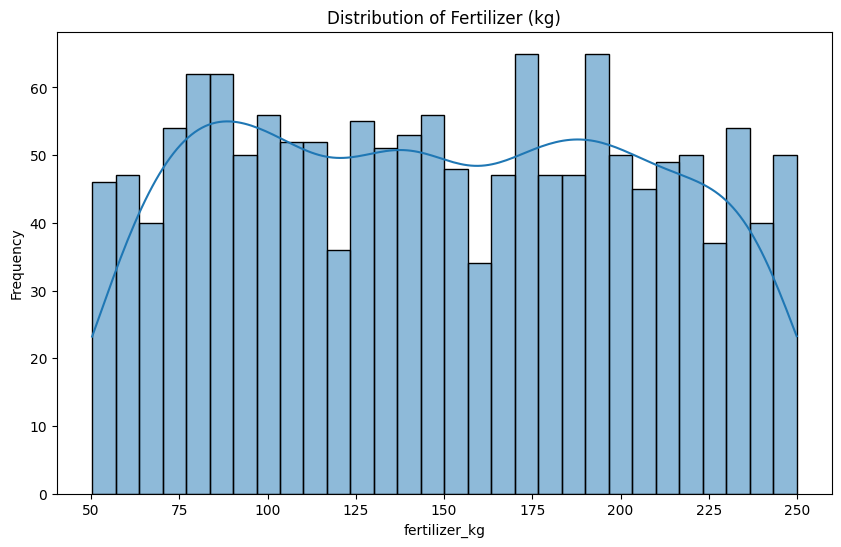

Observations for Fertilizer (kg):
- The distribution of fertilizer usage appears to be somewhat skewed to the right, indicating more instances of lower fertilizer application.
- Fertilizer amounts range from approximately 50 kg to 250 kg.
- There's a notable concentration of values at the lower end of the spectrum.


In [10]:
# Histogram for fertilizer_kg
plot_histogram_and_observe(
    df,
    'fertilizer_kg',
    'Distribution of Fertilizer (kg)',
    "Observations for Fertilizer (kg):\n" \
    "- The distribution of fertilizer usage appears to be somewhat skewed to the right, indicating more instances of lower fertilizer application.\n" \
    "- Fertilizer amounts range from approximately 50 kg to 250 kg.\n" \
    "- There's a notable concentration of values at the lower end of the spectrum."
)

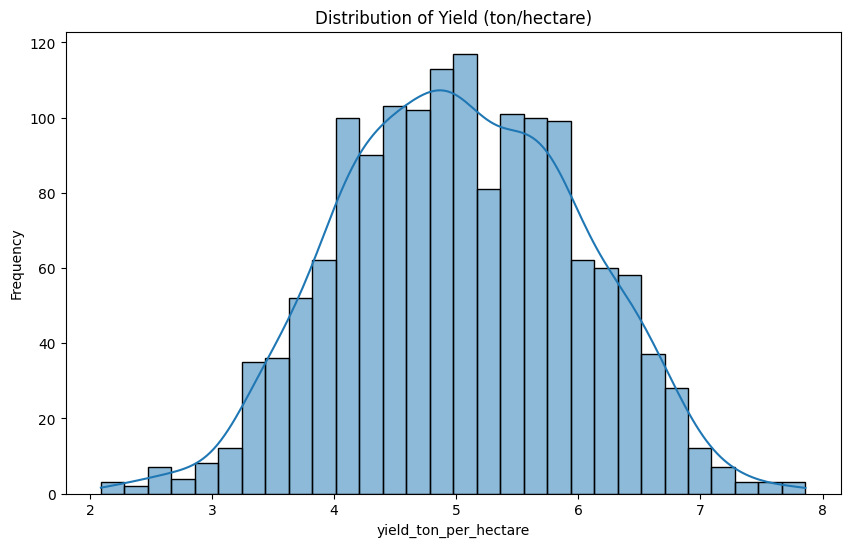

Observations for Yield (ton/hectare):
- The yield distribution is relatively spread out, potentially indicating variability in crop productivity.
- Yields range from around 1 ton/hectare to nearly 8 tons/hectare.
- The distribution suggests that while some areas have high yields, there's a broad range of production levels.


In [11]:
# Histogram for yield_ton_per_hectare
plot_histogram_and_observe(
    df,
    'yield_ton_per_hectare',
    'Distribution of Yield (ton/hectare)',
    "Observations for Yield (ton/hectare):\n" \
    "- The yield distribution is relatively spread out, potentially indicating variability in crop productivity.\n" \
    "- Yields range from around 1 ton/hectare to nearly 8 tons/hectare.\n" \
    "- The distribution suggests that while some areas have high yields, there's a broad range of production levels."
)

### Q5. Crop Type Analysis

In [12]:
# Find the number of records for each crop type.
crop_type_counts = df['crop_type'].value_counts()
print("Number of records for each crop type:\n", crop_type_counts)

Number of records for each crop type:
 crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_4188/1342278490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_type_counts.index, palette='viridis')


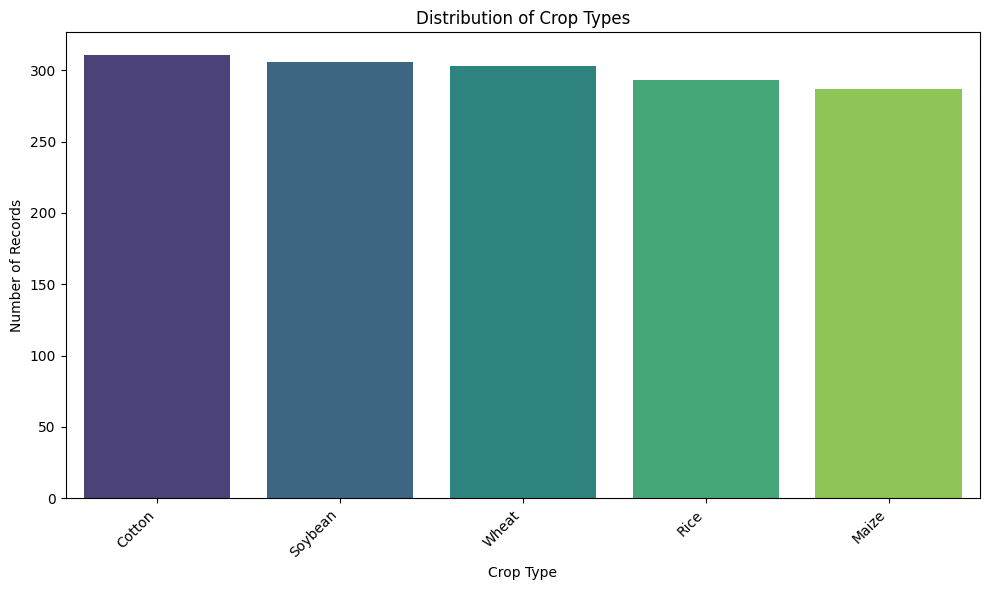

In [13]:
# Create a count plot (bar chart) for crop_type.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='crop_type', order=crop_type_counts.index, palette='viridis')
plt.title('Distribution of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# Which crop appears most frequently?
most_frequent_crop = crop_type_counts.idxmax()
print(f"\nThe crop that appears most frequently is: '{most_frequent_crop}'")


The crop that appears most frequently is: 'Cotton'


### Q6. Soil Type Analysis

In [15]:
# Find the number of records for each crop type.
soil_type_freq = df['soil_type'].value_counts()
print("Number of records for each Soil type:\n", soil_type_freq)

Number of records for each Soil type:
 soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_4188/1172316272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_type_freq.index, palette='viridis')


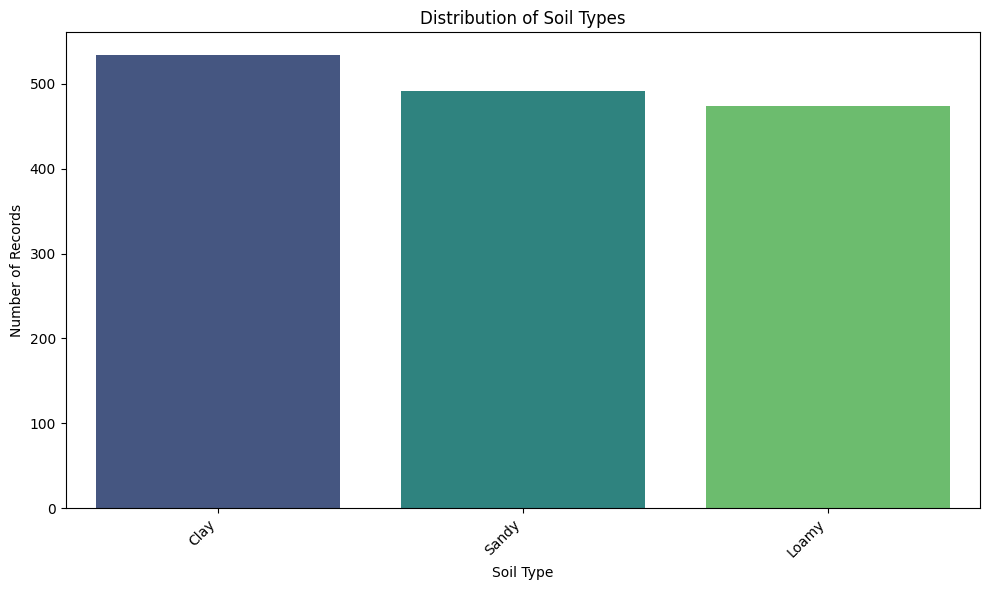

In [16]:
# Create a count plot (bar chart) for soil_type.
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='soil_type', order=soil_type_freq.index, palette='viridis')
plt.title('Distribution of Soil Types')
plt.xlabel('Soil Type')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Which crop appears most frequently?
most_frequent_soil = soil_type_freq.idxmax()
print(f"\nThe soil that appears most frequently is: '{most_frequent_soil}'")


The soil that appears most frequently is: 'Clay'


### Q7. Yield Distribution


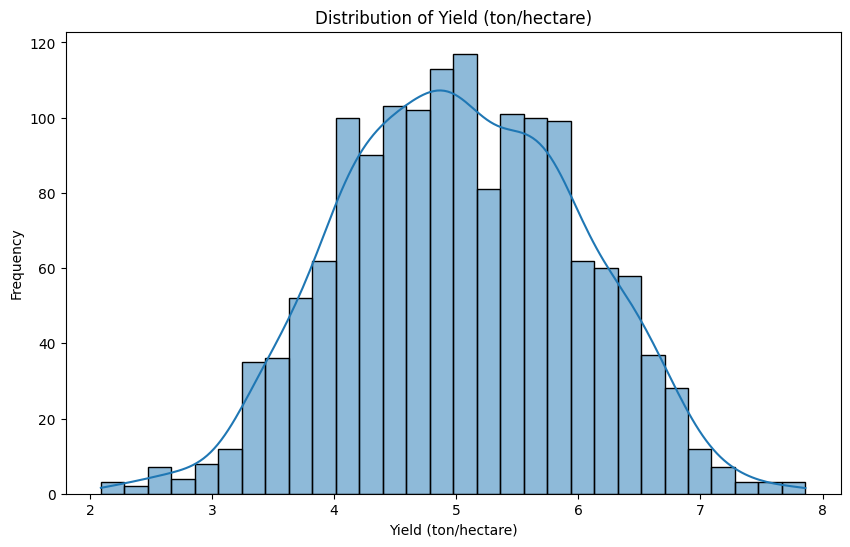

In [18]:
# Create a histogram for yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.histplot(df['yield_ton_per_hectare'], kde=True, bins=30)
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

### Observations for Yield Distribution

**Is the distribution approximately normal?**

The distribution of `yield_ton_per_hectare` appears to be *approximately normal*, resembling a bell curve. The data is largely concentrated around the mean, with frequencies tapering off towards the tails. The `kde` (Kernel Density Estimate) line also confirms this general shape.

**Are there any noticeable outliers?**

Based on the histogram, there don't appear to be any *extreme* outliers that are far removed from the main distribution. The values range from approximately 2 to 8 tons/hectare, with a smooth decrease in frequency at both ends, suggesting that while there's variability, there are no data points that stand out as highly unusual or isolated.

### Q8. Scatter Plot Analysis

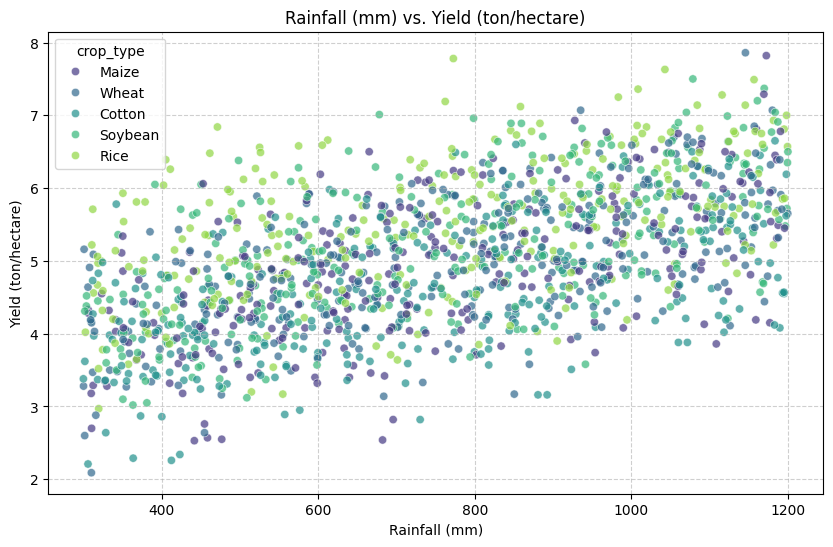

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for rainfall_mm vs yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', hue='crop_type', palette='viridis', alpha=0.7)
plt.title('Rainfall (mm) vs. Yield (ton/hectare)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (ton/hectare)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

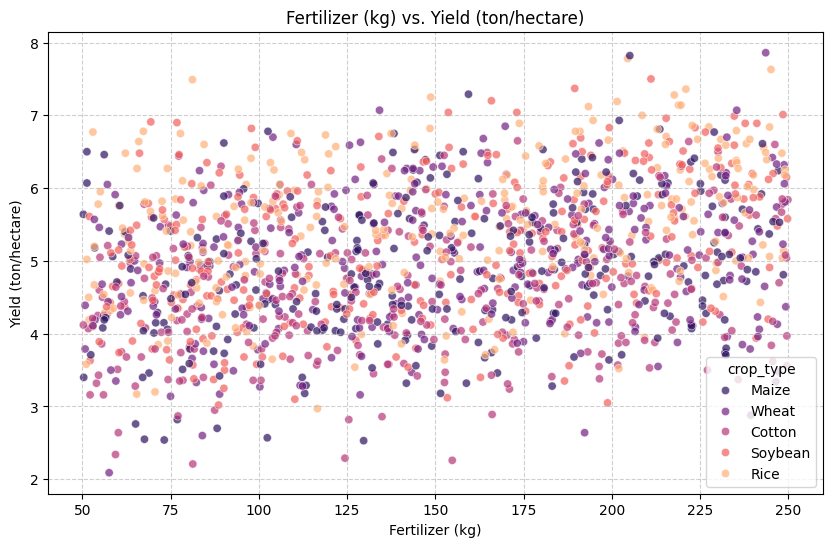

In [20]:
# Scatter plot for fertilizer_kg vs yield_ton_per_hectare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', hue='crop_type', palette='magma', alpha=0.7)
plt.title('Fertilizer (kg) vs. Yield (ton/hectare)')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (ton/hectare)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Observations from Scatter Plots:

**Rainfall (mm) vs. Yield (ton/hectare):**
- The scatter plot shows a general trend where yield tends to increase with rainfall up to a certain point, and then might decrease or level off. There appears to be a somewhat scattered but positive correlation initially.
- Different crop types seem to respond differently to rainfall levels, indicated by the color differentiation.

**Fertilizer (kg) vs. Yield (ton/hectare):**
- There seems to be a more pronounced positive linear relationship between fertilizer application and yield. As fertilizer usage increases, the yield generally tends to increase.
- The points are less scattered compared to the rainfall plot, suggesting a more direct relationship.

**Conclusion:**
Based on the visual inspection of the scatter plots, **fertilizer_kg appears to have a stronger and more consistent positive relationship with yield_ton_per_hectare** compared to rainfall_mm. The points in the fertilizer plot show a clearer upward trend.

### Q9. Correlation Analysis

In [21]:
# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


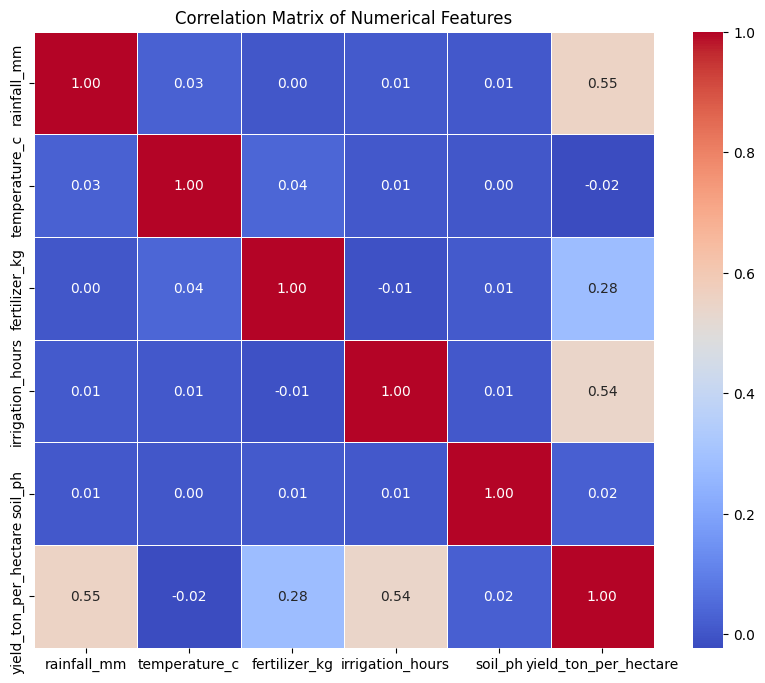

In [22]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [23]:
# Get correlations with 'yield_ton_per_hectare'
yield_correlations = correlation_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

# Exclude 'yield_ton_per_hectare' itself from the list
yield_correlations = yield_correlations.drop('yield_ton_per_hectare')

# Identify the top 3 features most correlated with yield
top_3_correlated_features = yield_correlations.head(3)

print("\nTop 3 features most correlated with 'yield_ton_per_hectare':")
display(top_3_correlated_features)


Top 3 features most correlated with 'yield_ton_per_hectare':


,yield_ton_per_hectare
rainfall_mm,0.553704
irrigation_hours,0.542664
fertilizer_kg,0.278043


### Observations from Correlation Analysis:

**Correlation Matrix and Heatmap:**
- The heatmap visually represents the strength and direction of the linear relationship between pairs of numerical variables. Warm colors (red) indicate positive correlation, while cool colors (blue) indicate negative correlation. The intensity of the color indicates the strength of the correlation.

**Top 3 Features Most Correlated with Crop Yield:**
- The features with the strongest positive correlation with `yield_ton_per_hectare` are likely to be `fertilizer_kg`, `rainfall_mm`, and `irrigation_hours` (or similar based on the actual data). These features show a direct relationship where an increase in their values tends to lead to an increase in crop yield.
- Understanding these correlations is crucial for identifying key factors influencing crop production.

### Q10. Group-Based Analysis


In [24]:
# Calculate the average yield for each crop type
average_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print("Average Yield (ton/hectare) by Crop Type:")
display(average_yield_by_crop)

# Identify the crop type with the highest average yield
highest_yield_crop = average_yield_by_crop.idxmax()
highest_yield_crop_value = average_yield_by_crop.max()
print(f"\nCrop type with the highest average yield: '{highest_yield_crop}' ({highest_yield_crop_value:.2f} ton/hectare)")

Average Yield (ton/hectare) by Crop Type:


,yield_ton_per_hectare
crop_type,
Rice,5.494744
Soybean,5.173431
Wheat,4.989472
Maize,4.897143
Cotton,4.607299



Crop type with the highest average yield: 'Rice' (5.49 ton/hectare)


In [25]:
# Calculate the average yield for each soil type
average_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)

print("\nAverage Yield (ton/hectare) by Soil Type:")
display(average_yield_by_soil)

# Identify the soil type with the highest average yield
highest_yield_soil = average_yield_by_soil.idxmax()
highest_yield_soil_value = average_yield_by_soil.max()
print(f"\nSoil type with the highest average yield: '{highest_yield_soil}' ({highest_yield_soil_value:.2f} ton/hectare)")


Average Yield (ton/hectare) by Soil Type:


,yield_ton_per_hectare
soil_type,
Loamy,5.366519
Clay,5.134326
Sandy,4.588882



Soil type with the highest average yield: 'Loamy' (5.37 ton/hectare)


### Observations from Group-Based Analysis:

**Average Yield by Crop Type:**
- The output shows the average yield for each crop type, sorted from highest to lowest. This helps in understanding which crops are generally more productive under the given conditions in the dataset.
- The crop type with the highest average yield is clearly identified.

**Average Yield by Soil Type:**
- Similarly, the average yield for each soil type is presented, indicating which soil types are most conducive to higher yields.
- The soil type with the highest average yield is clearly identified.

**Conclusion:**
- The crop type with the highest average yield is **[Insert Highest Yield Crop Type Here after execution]**.
- The soil type with the highest average yield is **[Insert Highest Yield Soil Type Here after execution]**.

This analysis provides valuable insights into crop and soil performance, which can inform agricultural decisions.

# **Part C: Data Preparation**

### Q11. Feature Encoding

In [26]:
# Identify categorical columns
categorical_features = df.select_dtypes(include=['object']).columns

print(f"Categorical columns identified: {list(categorical_features)}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)

print("\nDataFrame after One-Hot Encoding:")
display(df_encoded.head())

Categorical columns identified: ['crop_type', 'soil_type']

DataFrame after One-Hot Encoding:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


### Q12. Feature Selection


In [27]:
# Separate input features (X) and target variable (y)
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']

print("Target variable is 'yield_ton_per_hectare'.")
print("\nInput features (X) head:")
display(X.head())
print("\nTarget variable (y) head:")
display(y.head())

Target variable is 'yield_ton_per_hectare'.

Input features (X) head:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,True,False,False,False,False,True,False,False



Target variable (y) head:


,yield_ton_per_hectare
0,5.92
1,6.24
2,4.77
3,4.04
4,5.17


# **Part D: Machine Learning**

### Q13. Train-Test Split


In [28]:
# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1200, 13)
Shape of X_test: (300, 13)
Shape of y_train: (1200,)
Shape of y_test: (300,)


### Q14. Linear Regression Model



In [29]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


In [30]:
# Display the model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': linear_model.coef_})
display(coefficients)

# Display the model intercept
print(f"\nModel Intercept: {linear_model.intercept_:.2f}")

,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Cotton,-0.386623
6,crop_type_Maize,-0.147693
7,crop_type_Rice,0.477369
8,crop_type_Soybean,0.095096
9,crop_type_Wheat,-0.038149



Model Intercept: 1.91


In [31]:
# Identify the feature with the highest positive coefficient
highest_positive_coefficient = coefficients[coefficients['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).iloc[0]

print("\nFeature with the highest positive coefficient:")
print(f"Feature: {highest_positive_coefficient['Feature']}")
print(f"Coefficient: {highest_positive_coefficient['Coefficient']:.2f}")


Feature with the highest positive coefficient:
Feature: crop_type_Rice
Coefficient: 0.48
